In [36]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path(r"../data/processed form/used_cars_cleaned.csv")
df = pd.read_csv(DATA_PATH)
sns.set_theme(style="whitegrid", palette="deep")
print(df.shape)
df.head()

(6019, 14)


,name,brand,location,year,vehicle_age,kilometers_driven,fuel_type,transmission,owner_type,mileage_kmpl,engine_cc,power_bhp,seats,price
0,Maruti Wagon R LXI CNG,Maruti,Mumbai,2010,10,72000.0,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Hyundai,Pune,2015,5,41000.0,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50
2,Honda Jazz V,Honda,Chennai,2011,9,46000.0,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50
3,Maruti Ertiga VDI,Maruti,Chennai,2012,8,87000.0,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,Audi,Coimbatore,2013,7,40670.0,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74


In [37]:
df_train = df.dropna(subset=["price"]).copy()

print("Raw rows:", len(df))
print("Training rows with known price:", len(df_train))
print("Rows excluded due to missing price:", len(df) - len(df_train))

Raw rows: 6019
Training rows with known price: 6019
Rows excluded due to missing price: 0


In [38]:
df_train = df.copy()

print("Training rows:", len(df_train))
print("Missing prices:", df_train["price"].isna().sum())

Training rows: 6019
Missing prices: 0


In [39]:
import numpy as np

df_train.loc[df_train["mileage_kmpl"] <= 0, "mileage_kmpl"] = np.nan
df_train.loc[df_train["seats"] <= 0, "seats"] = np.nan
df_train.loc[df_train["engine_cc"] < 500, "engine_cc"] = np.nan
df_train.loc[
    df_train["kilometers_driven"] > 500_000,
    "kilometers_driven"
] = np.nan

print("Cleaning complete.")

Cleaning complete.


In [40]:
quality_checks_after = pd.Series({
    "Training rows": len(df_train),
    "Missing mileage_kmpl": df_train["mileage_kmpl"].isna().sum(),
    "Missing engine_cc": df_train["engine_cc"].isna().sum(),
    "Missing power_bhp": df_train["power_bhp"].isna().sum(),
    "Missing seats": df_train["seats"].isna().sum(),
    "Zero or negative mileage": (df_train["mileage_kmpl"] <= 0).sum(),
    "Invalid seats (<= 0)": (df_train["seats"] <= 0).sum(),
    "Engine below 500 cc": (df_train["engine_cc"] < 500).sum(),
    "Kilometres above 500,000": (
        df_train["kilometers_driven"] > 500_000
    ).sum(),
    "Missing target price": df_train["price"].isna().sum(),
})

quality_checks_after

Training rows               6019
Missing mileage_kmpl          70
Missing engine_cc             37
Missing power_bhp            143
Missing seats                 43
Zero or negative mileage       0
Invalid seats (<= 0)           0
Engine below 500 cc            0
Kilometres above 500,000       0
Missing target price           0
dtype: int64

In [41]:
model_columns = [
    "name",
    "brand",
    "location",
    "year",
    "vehicle_age",
    "kilometers_driven",
    "fuel_type",
    "transmission",
    "owner_type",
    "mileage_kmpl",
    "engine_cc",
    "power_bhp",
    "seats",
    "price",
]

df_model = df_train[model_columns].copy()

print("Final modelling dataset shape:", df_model.shape)

display(df_model.head())

print("\nMissing values:")
display(
    df_model.isna()
    .sum()
    .sort_values(ascending=False)
)

Final modelling dataset shape: (6019, 14)


,name,brand,location,year,vehicle_age,kilometers_driven,fuel_type,transmission,owner_type,mileage_kmpl,engine_cc,power_bhp,seats,price
0,Maruti Wagon R LXI CNG,Maruti,Mumbai,2010,10,72000.0,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Hyundai,Pune,2015,5,41000.0,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50
2,Honda Jazz V,Honda,Chennai,2011,9,46000.0,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50
3,Maruti Ertiga VDI,Maruti,Chennai,2012,8,87000.0,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,Audi,Coimbatore,2013,7,40670.0,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74



Missing values:


power_bhp            143
mileage_kmpl          70
seats                 43
engine_cc             37
kilometers_driven      4
name                   0
vehicle_age            0
year                   0
location               0
brand                  0
owner_type             0
transmission           0
fuel_type              0
price                  0
dtype: int64

In [42]:
from pathlib import Path

OUTPUT_PATH = Path(r"../data/processed form/used_cars_cleaned.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df_model.to_csv(OUTPUT_PATH, index=False)

print("Saved file:", OUTPUT_PATH.resolve())
print("File exists:", OUTPUT_PATH.exists())
print("File size:", OUTPUT_PATH.stat().st_size, "bytes")

Saved file: C:\Users\kenda\Documents\Projects\used-car-price-prediction\data\processed form\used_cars_cleaned.csv
File exists: True
File size: 639267 bytes


In [43]:
df_check = pd.read_csv(OUTPUT_PATH)

print("Reloaded shape:", df_check.shape)
display(df_check.head())
assert df_check.shape == df_model.shape
assert df_check["price"].isna().sum() == 0

print("Saved dataset verification passed.")

Reloaded shape: (6019, 14)


,name,brand,location,year,vehicle_age,kilometers_driven,fuel_type,transmission,owner_type,mileage_kmpl,engine_cc,power_bhp,seats,price
0,Maruti Wagon R LXI CNG,Maruti,Mumbai,2010,10,72000.0,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Hyundai,Pune,2015,5,41000.0,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50
2,Honda Jazz V,Honda,Chennai,2011,9,46000.0,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50
3,Maruti Ertiga VDI,Maruti,Chennai,2012,8,87000.0,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,Audi,Coimbatore,2013,7,40670.0,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74


Saved dataset verification passed.


# Exploratory Data Analysis

This notebook explores the distribution of used-car prices and the vehicle characteristics associated with those prices.

Questions explored:
1. How are used-car prices distributed?
2. Which manufacturers have the highest typical listing prices?
3. How are age and kilometres driven related to price?
4. How do fuel type, transmission, ownership history, and location relate to price?
5. Which numerical features show the strongest linear associations with price?

In [44]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

DATA_PATH = Path(r"../data/processed form/used_cars_cleaned.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (6019, 14)


,name,brand,location,year,vehicle_age,kilometers_driven,fuel_type,transmission,owner_type,mileage_kmpl,engine_cc,power_bhp,seats,price
0,Maruti Wagon R LXI CNG,Maruti,Mumbai,2010,10,72000.0,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Hyundai,Pune,2015,5,41000.0,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50
2,Honda Jazz V,Honda,Chennai,2011,9,46000.0,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50
3,Maruti Ertiga VDI,Maruti,Chennai,2012,8,87000.0,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,Audi,Coimbatore,2013,7,40670.0,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74


## Price distribution

This section examines the distribution of used-car listing prices. Because premium and luxury vehicles can have much higher prices than the majority of listings, the distribution may be right-skewed.

In [45]:
price_summary = df["price"].describe()

display(price_summary.to_frame(name="price"))

print(f"Median price: {df['price'].median():.2f}")
print(f"Mean price:   {df['price'].mean():.2f}")
print(f"Maximum:      {df['price'].max():.2f}")

,price
count,6019.000000
mean,9.479468
std,11.187917
min,0.440000
25%,3.500000
50%,5.640000
75%,9.950000
max,160.000000


Median price: 5.64
Mean price:   9.48
Maximum:      160.00


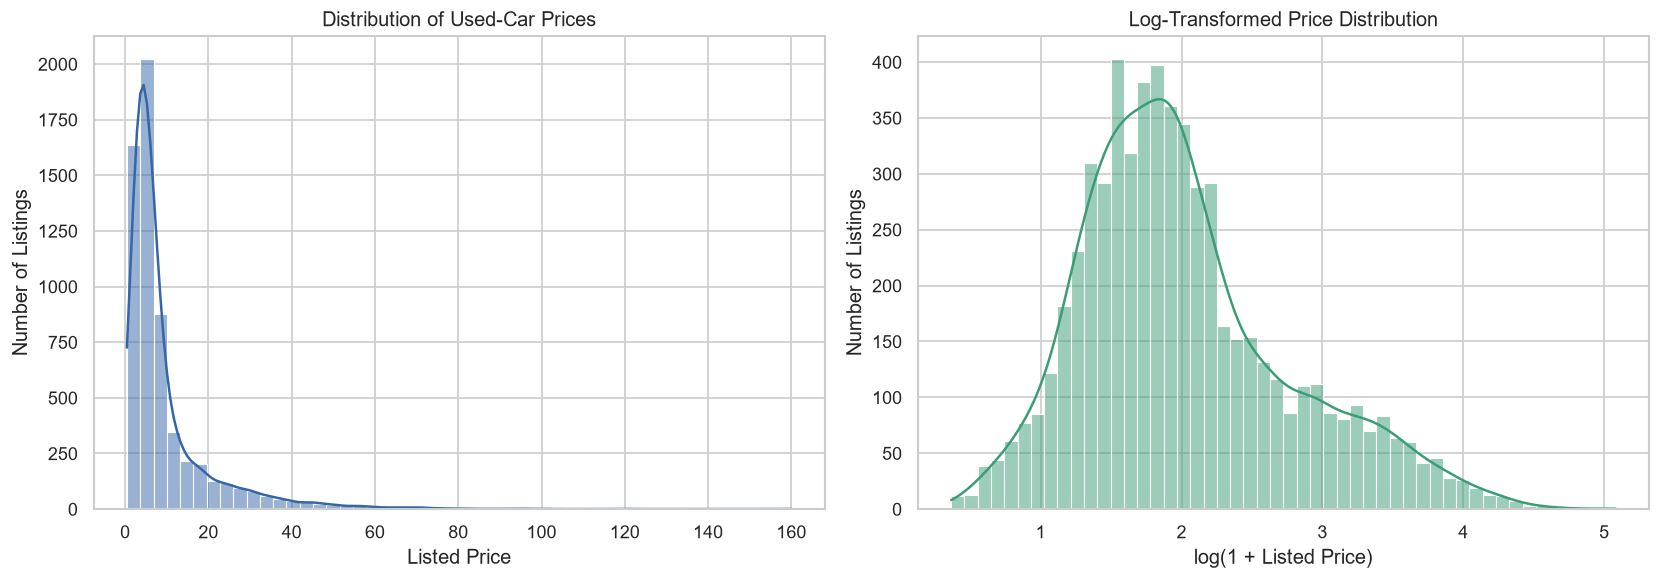

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df,
    x="price",
    bins=50,
    kde=True,
    ax=axes[0],
    color="#3566a8"
)
axes[0].set_title("Distribution of Used-Car Prices")
axes[0].set_xlabel("Listed Price")
axes[0].set_ylabel("Number of Listings")

sns.histplot(
    data=df,
    x=np.log1p(df["price"]),
    bins=50,
    kde=True,
    ax=axes[1],
    color="#3a9d76"
)
axes[1].set_title("Log-Transformed Price Distribution")
axes[1].set_xlabel("log(1 + Listed Price)")
axes[1].set_ylabel("Number of Listings")

plt.tight_layout()
plt.show()

In [47]:
FIGURES_PATH = Path("../outputs/figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

fig.savefig(
    FIGURES_PATH / "price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

### Interpretation

Used-car listing prices are right-skewed: the mean price is higher than the median price, indicating that a relatively small number of expensive vehicles pull the average upward. The log-transformed distribution is more compact and easier to inspect. This suggests that modelling `log1p(price)` should be considered as a later experiment, although model errors should still be reported on the original price scale.

## Brand pricing

The analysis compares typical prices by manufacturer. Brands with very few listings are excluded to avoid treating a one-off premium listing as representative of a brand.

In [48]:
brand_summary = (
    df.groupby("brand")
    .agg(
        listings=("price", "size"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        min_price=("price", "min"),
        max_price=("price", "max")
    )
    .query("listings >= 20")
    .sort_values("median_price", ascending=False)
)

display(brand_summary.head(15))

,listings,median_price,mean_price,min_price,max_price
brand,,,,,
Land,60,35.000,39.259500,11.00,160.00
Jaguar,40,31.900,37.632250,16.00,100.00
Mini,26,24.285,26.896923,17.00,39.75
Mercedes-Benz,318,24.000,26.809874,3.90,90.00
Audi,236,23.500,25.537712,7.50,72.94
BMW,267,21.000,25.243146,6.30,93.67
Volvo,21,18.250,18.802857,7.25,32.50
Toyota,411,10.750,11.580024,1.50,35.82
Mitsubishi,27,9.950,11.058889,1.00,28.00


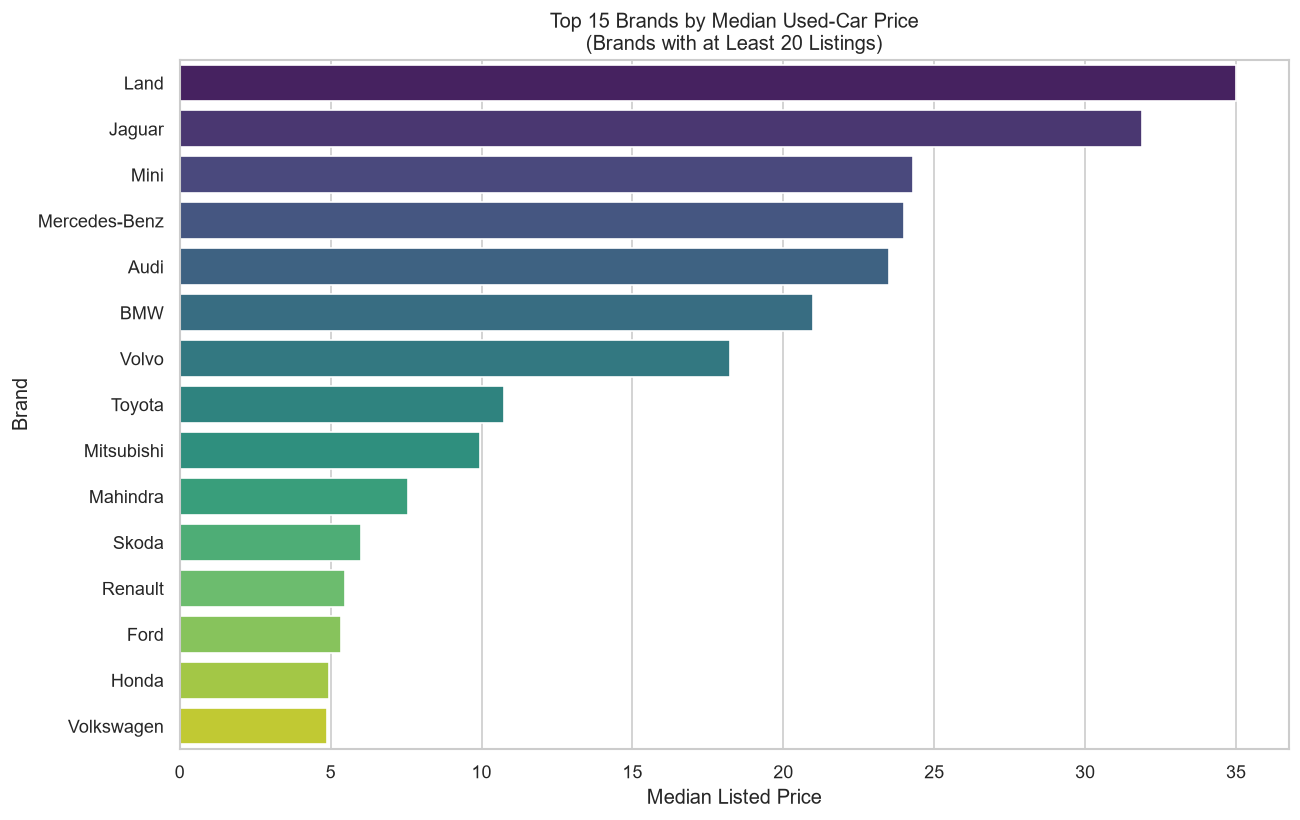

In [49]:
top_brands = brand_summary.head(15).reset_index()

fig, ax = plt.subplots(figsize=(11, 7))

sns.barplot(
    data=top_brands,
    x="median_price",
    y="brand",
    hue="brand",
    palette="viridis",
    legend=False,
    ax=ax
)

ax.set_title("Top 15 Brands by Median Used-Car Price\n(Brands with at Least 20 Listings)")
ax.set_xlabel("Median Listed Price")
ax.set_ylabel("Brand")

plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES_PATH / "top_brands_median_price.png",
    dpi=300,
    bbox_inches="tight"
)

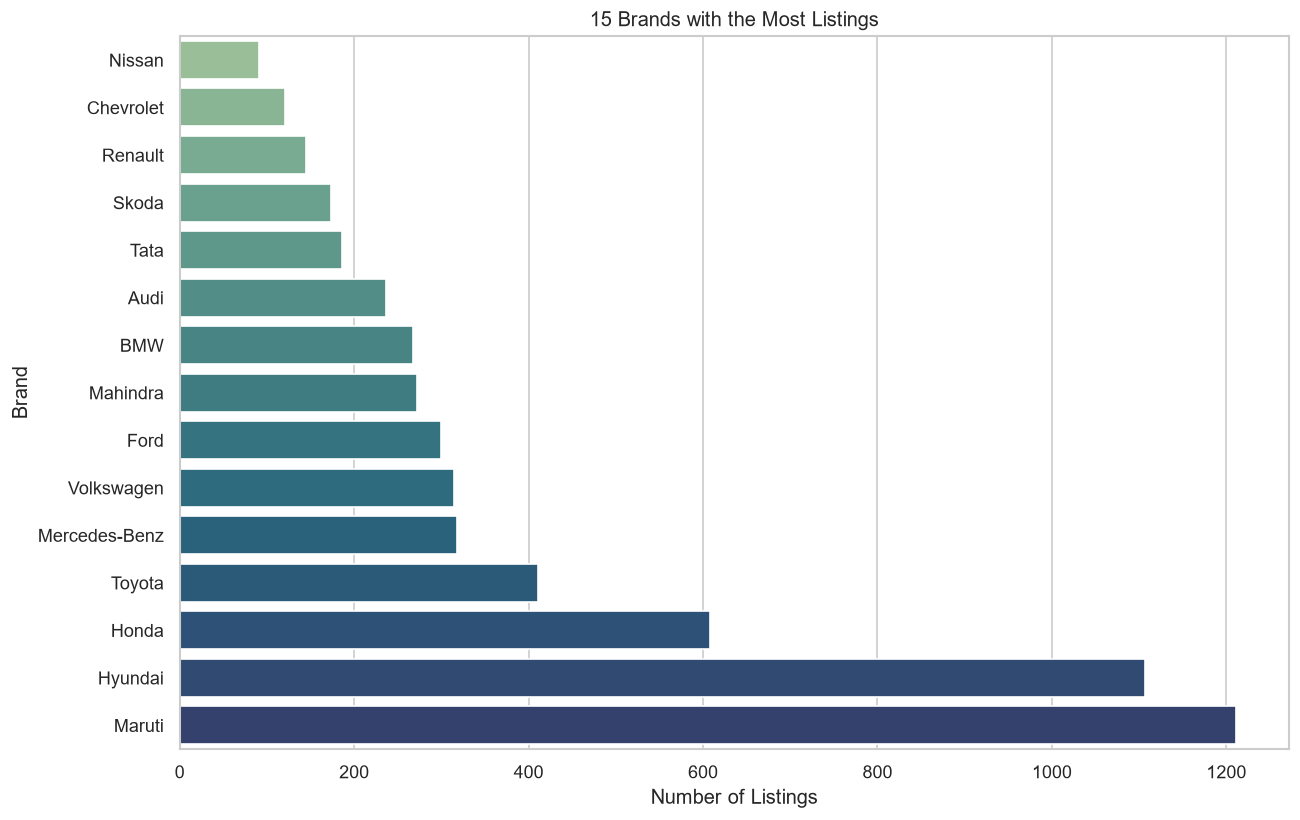

In [50]:
top_listing_brands = (
    df["brand"]
    .value_counts()
    .head(15)
    .sort_values()
    .reset_index()
)

top_listing_brands.columns = ["brand", "listings"]

fig, ax = plt.subplots(figsize=(11, 7))

sns.barplot(
    data=top_listing_brands,
    x="listings",
    y="brand",
    hue="brand",
    palette="crest",
    legend=False,
    ax=ax
)

ax.set_title("15 Brands with the Most Listings")
ax.set_xlabel("Number of Listings")
ax.set_ylabel("Brand")

plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES_PATH / "brands_by_listing_count.png",
    dpi=300,
    bbox_inches="tight"
)

## Vehicle condition proxies

Vehicle age and kilometres driven are proxies for depreciation and vehicle usage. Both are expected to have a relationship with listing price, though that relationship can vary substantially by brand, model, and condition.

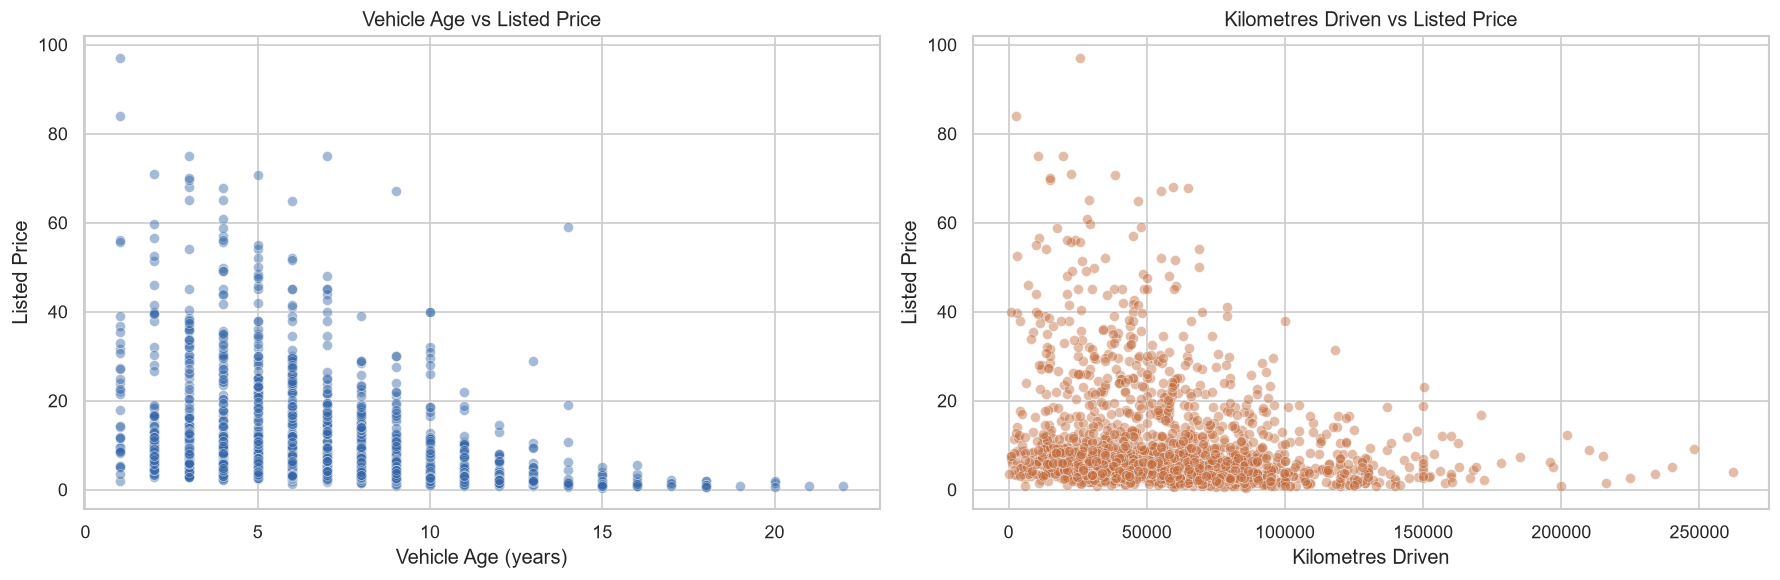

In [51]:
plot_sample = df.sample(
    n=min(2_000, len(df)),
    random_state=42
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data=plot_sample,
    x="vehicle_age",
    y="price",
    alpha=0.45,
    ax=axes[0],
    color="#3566a8"
)
axes[0].set_title("Vehicle Age vs Listed Price")
axes[0].set_xlabel("Vehicle Age (years)")
axes[0].set_ylabel("Listed Price")

sns.scatterplot(
    data=plot_sample,
    x="kilometers_driven",
    y="price",
    alpha=0.45,
    ax=axes[1],
    color="#c26b3c"
)
axes[1].set_title("Kilometres Driven vs Listed Price")
axes[1].set_xlabel("Kilometres Driven")
axes[1].set_ylabel("Listed Price")

plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES_PATH / "age_and_kilometres_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)

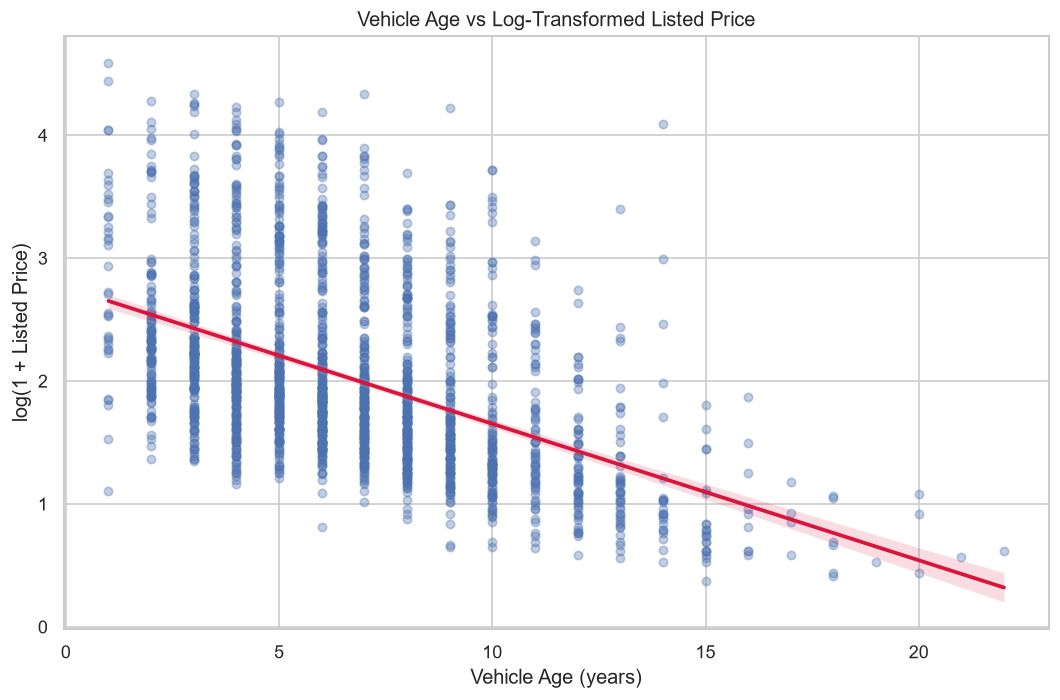

In [52]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.regplot(
    data=plot_sample,
    x="vehicle_age",
    y=np.log1p(plot_sample["price"]),
    scatter_kws={"alpha": 0.35, "s": 25},
    line_kws={"color": "crimson"},
    ax=ax
)

ax.set_title("Vehicle Age vs Log-Transformed Listed Price")
ax.set_xlabel("Vehicle Age (years)")
ax.set_ylabel("log(1 + Listed Price)")

plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES_PATH / "vehicle_age_vs_log_price.png",
    dpi=300,
    bbox_inches="tight"
)

## Price by vehicle attributes

The following comparisons examine whether price distributions differ across fuel type, transmission type, ownership history, and location.

In [53]:
def category_price_summary(data, column):
    return (
        data.groupby(column)
        .agg(
            listings=("price", "size"),
            median_price=("price", "median"),
            mean_price=("price", "mean")
        )
        .sort_values("median_price", ascending=False)
    )

for column in ["fuel_type", "transmission", "owner_type", "location"]:
    print(f"\n{column.upper()}")
    display(category_price_summary(df, column))


FUEL_TYPE


,listings,median_price,mean_price
fuel_type,,,
Electric,2,12.875,12.875000
Diesel,3205,7.750,12.840605
Petrol,2746,4.105,5.701100
CNG,56,3.250,3.516786
LPG,10,2.600,2.487000



TRANSMISSION


,listings,median_price,mean_price
transmission,,,
Automatic,1720,16.0,19.843971
Manual,4299,4.5,5.332703



OWNER_TYPE


,listings,median_price,mean_price
owner_type,,,
First,4929,5.91,9.962445
Second,968,4.27,7.599886
Fourth & Above,9,3.00,3.280000
Third,113,2.65,5.007257



LOCATION


,listings,median_price,mean_price
location,,,
Coimbatore,636,8.305,15.078223
Bangalore,358,6.850,13.328631
Kochi,651,6.710,11.179186
Ahmedabad,224,5.900,8.457321
Hyderabad,742,5.800,9.776550
Mumbai,790,5.750,9.429329
Delhi,554,5.500,9.707726
Chennai,494,4.500,7.753623
Jaipur,413,4.250,5.809225


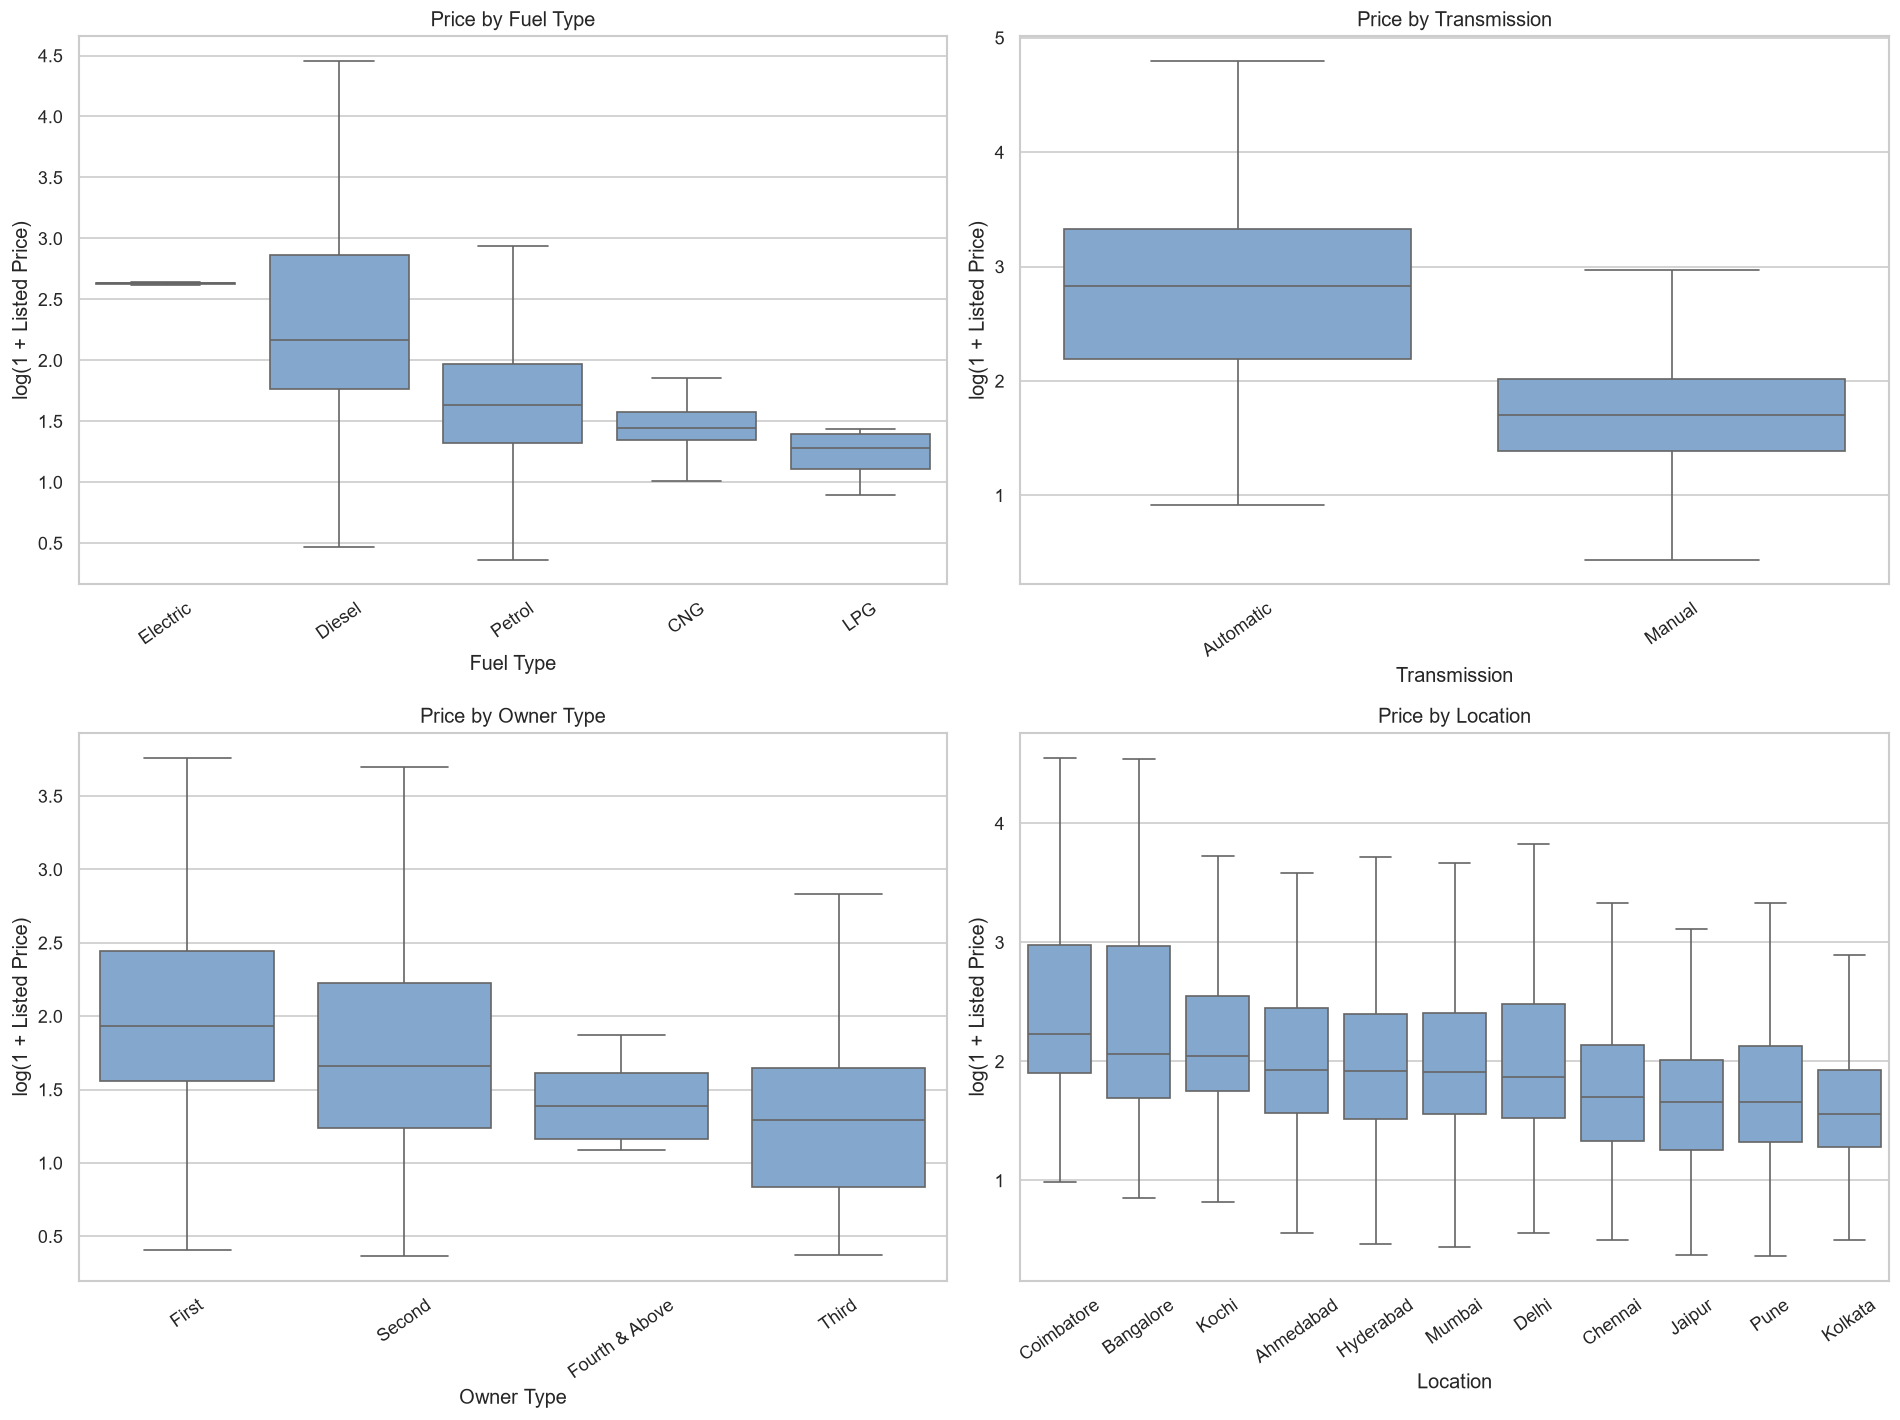

In [54]:
categorical_columns = [
    "fuel_type",
    "transmission",
    "owner_type",
    "location",
]

titles = [
    "Price by Fuel Type",
    "Price by Transmission",
    "Price by Owner Type",
    "Price by Location",
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, column, title in zip(axes, categorical_columns, titles):
    order = (
        df.groupby(column)["price"]
        .median()
        .sort_values(ascending=False)
        .index
    )

    sns.boxplot(
        data=df,
        x=column,
        y=np.log1p(df["price"]),
        order=order,
        ax=ax,
        color="#77a6d9",
        showfliers=False
    )

    ax.set_title(title)
    ax.set_xlabel(column.replace("_", " ").title())
    ax.set_ylabel("log(1 + Listed Price)")
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES_PATH / "price_by_categorical_features.png",
    dpi=300,
    bbox_inches="tight"
)

## Numeric feature correlations

Correlation quantifies linear association only. It does not prove causation and may not capture non-linear relationships or interactions between vehicle features.

In [55]:
numeric_columns = [
    "price",
    "vehicle_age",
    "kilometers_driven",
    "mileage_kmpl",
    "engine_cc",
    "power_bhp",
    "seats",
]

correlation_matrix = df[numeric_columns].corr(numeric_only=True)

display(correlation_matrix["price"].sort_values(ascending=False).to_frame("correlation_with_price"))

,correlation_with_price
price,1.000000
power_bhp,0.772566
engine_cc,0.658859
seats,0.053247
kilometers_driven,-0.179016
vehicle_age,-0.305327
mileage_kmpl,-0.333263


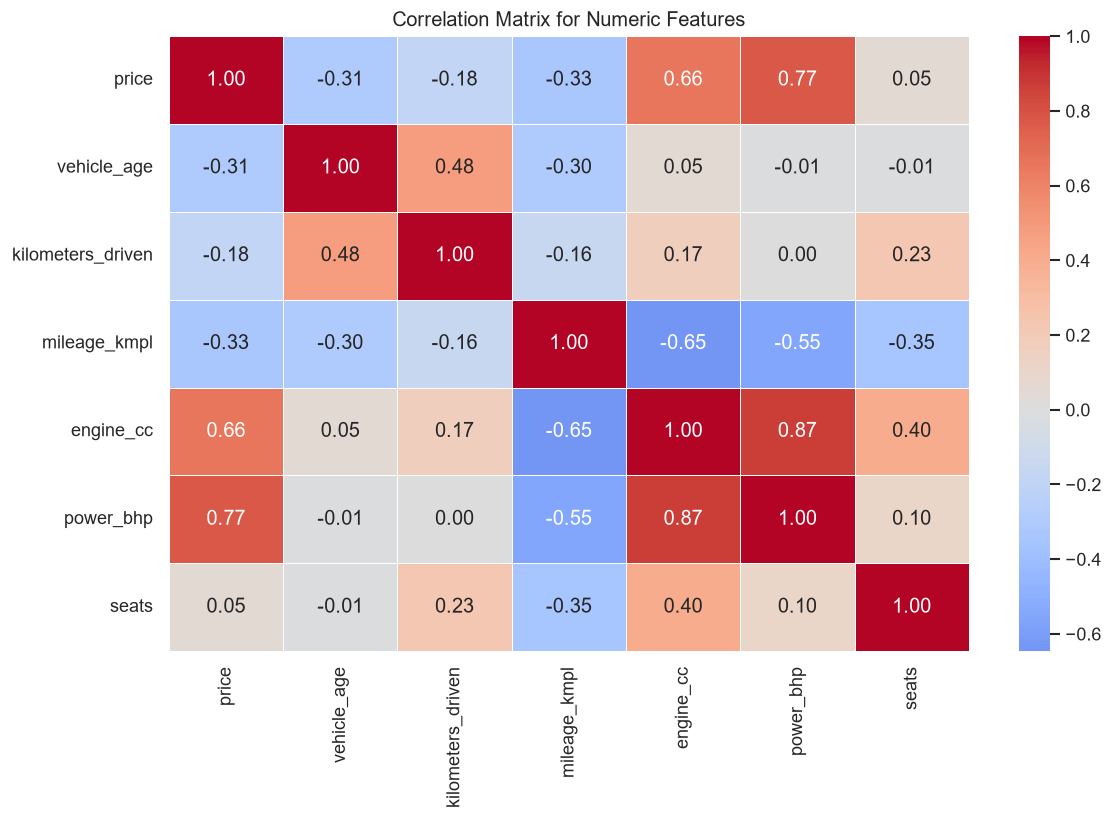

In [56]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Correlation Matrix for Numeric Features")

plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES_PATH / "numeric_feature_correlations.png",
    dpi=300,
    bbox_inches="tight"
)

# EDA Conclusions

- Used-car listing prices are **right-skewed** (skewness ≈ 3.3), with a median of 5.64 lakh and a mean of 9.48 lakh. A relatively small number of premium listings therefore raise the arithmetic average above the typical listing price.

- Price varies substantially by manufacturer. Typical prices range from approximately 3–5 lakh for high-volume brands such as Maruti and Hyundai to roughly 21–35 lakh for luxury brands such as BMW, Audi, Mercedes-Benz, Jaguar, and Land Rover. Brand should therefore be retained as a categorical feature in the prediction model.

- Vehicle age has a negative association with price (Pearson correlation ≈ −0.31 with raw price and ≈ −0.47 with `log1p(price)`). This is consistent with a non-linear depreciation pattern, although vehicle age is not the only factor influencing price.

- Kilometres driven has a weak negative association with price (Pearson correlation ≈ −0.18). Mileage alone is not a strong price predictor, but it may become more useful when combined with age, brand, fuel type, and technical features.

- Engine displacement and power show strong positive associations with price (`power_bhp`: ≈ +0.77; `engine_cc`: ≈ +0.66). These variables are also correlated with one another (≈ +0.70), so their relationship should be considered during model selection and interpretation.

- Price distributions vary by fuel type, transmission, ownership history, and location. Diesel vehicles have higher typical listed prices than petrol, CNG, and LPG vehicles in this dataset; automatic vehicles have a median price of approximately 16.0 lakh, compared with approximately 4.5 lakh for manual vehicles. First-owner vehicles have a higher median price (5.91 lakh) than second-owner (4.27 lakh) and third-owner listings (2.65 lakh).

- Applying `log1p(price)` reduces target skewness from approximately 3.3 to 0.75. This supports comparing a model trained on raw prices with a model trained on log-transformed prices, while evaluating final prediction error after converting predictions back to the original lakh price scale.